# Time-of-Day Clustering

**Goal:** Identify characteristic 24-hour price *shapes* to capture structural market behaviors such as the overnight price drop and daytime peaks.

---

## 1. Setup and Load Data

Import libraries and load the cleaned dataset.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour

print(f"Loaded {len(df):,} rows spanning {df['date'].nunique()} unique days ({df['time'].min().date()} → {df['time'].max().date()})")

Loaded 96,133 rows spanning 4010 unique days (2015-01-04 → 2025-12-31)


## 2. Build Daily Price Profiles

Pivot the data so that each row represents a single date and each column (0–23) holds the electricity price at that hour. This produces a 24-dimensional *price shape* for every day in the dataset.

In [51]:
pivot_df = df.pivot(index='date', columns='hour', values='price').dropna()

print(f"Price profile matrix: {pivot_df.shape[0]} days × {pivot_df.shape[1]} hours")
print(pivot_df.head())

Price profile matrix: 3991 days × 24 hours
hour           0      1      2      3      4      5      6      7      8   \
date                                                                        
2015-01-05  34.94  32.19  28.05  28.04  34.26  37.80  50.38  50.97  41.51   
2015-01-06  35.04  34.50  33.47  33.97  36.02  39.96  42.66  44.94  50.87   
2015-01-07  34.31  32.55  32.08  29.48  34.94  35.78  45.98  47.91  48.91   
2015-01-08  32.32  31.10  30.17  24.54  32.00  38.81  42.44  45.55  48.75   
2015-01-09  29.71  28.97  25.12  25.46  25.84  31.86  44.00  45.82  47.16   

hour           9   ...     14     15     16     17     18     19     20  \
date               ...                                                    
2015-01-05  40.46  ...  43.10  46.70  56.78  58.84  49.23  44.32  40.00   
2015-01-06  50.86  ...  40.08  43.62  48.55  45.71  39.94  44.94  42.51   
2015-01-07  50.00  ...  48.00  47.14  51.07  47.42  44.83  39.10  42.00   
2015-01-08  49.29  ...  40.50  41.10  54.5

## 3. Standardize the Shapes

Scaling ensures clustering is driven by *shape* (relative intraday movement), not absolute price level.

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot_df)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean ≈ {X_scaled.mean():.4f}, Std ≈ {X_scaled.std():.4f}  (should be ~0 and ~1)")

Scaled matrix shape: (3991, 24)
Mean ≈ 0.0000, Std ≈ 1.0000  (should be ~0 and ~1)


## 4. Fit K-Means Clustering

Use `k = 4` to discover the primary daily price regimes present in the market.

In [53]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pivot_df['cluster'] = kmeans.fit_predict(X_scaled)

counts = pivot_df['cluster'].value_counts().sort_index()
print("Days per cluster:")
for cluster, n in counts.items():
    print(f"  Cluster {cluster}: {n} days ({n / len(pivot_df) * 100:.1f}%)")

Days per cluster:
  Cluster 0: 2581 days (64.7%)
  Cluster 1: 311 days (7.8%)
  Cluster 2: 108 days (2.7%)
  Cluster 3: 991 days (24.8%)


## 5. Visualize Mean Profile per Cluster

Plot the average 24-hour price curve for each cluster to interpret the market behavior each group represents (e.g. overnight dip, morning peak, flat industrial day).

  Cluster 0 peak hour: 17h  (55.5 EUR/MWh)  |  trough:  2h  (31.2 EUR/MWh)
  Cluster 1 peak hour: 17h  (268.9 EUR/MWh)  |  trough:  2h  (158.6 EUR/MWh)
  Cluster 2 peak hour: 17h  (504.9 EUR/MWh)  |  trough: 12h  (311.1 EUR/MWh)
  Cluster 3 peak hour: 17h  (142.5 EUR/MWh)  |  trough: 12h  (64.3 EUR/MWh)


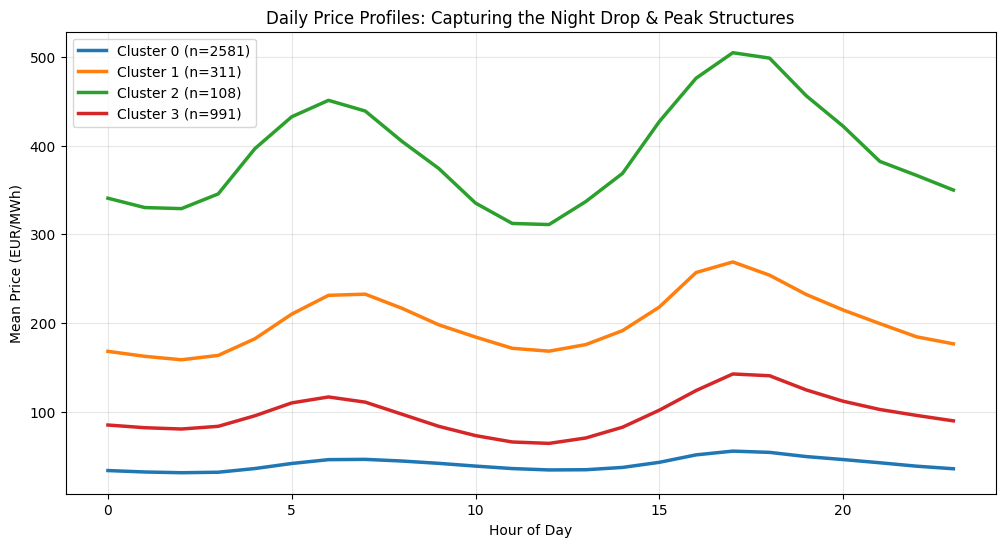

In [54]:
plt.figure(figsize=(12, 6))
for c in range(4):
    cluster_avg = pivot_df[pivot_df['cluster'] == c].drop('cluster', axis=1).mean()
    n = len(pivot_df[pivot_df['cluster'] == c])
    plt.plot(cluster_avg, label=f'Cluster {c} (n={n})', lw=2.5)
    print(f"  Cluster {c} peak hour: {cluster_avg.idxmax():>2}h  ({cluster_avg.max():.1f} EUR/MWh)  |  trough: {cluster_avg.idxmin():>2}h  ({cluster_avg.min():.1f} EUR/MWh)")

plt.title('Daily Price Profiles: Capturing the Night Drop & Peak Structures')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Price (EUR/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. What Days Belong to Each Cluster?

A price-shape cluster is only interpretable if we can describe *what kind of day* it represents. Here we break each cluster down by day-of-week and by month to see whether the shape profiles correspond to recognisable real-world patterns (e.g. weekends vs. weekdays, summer solar effect).

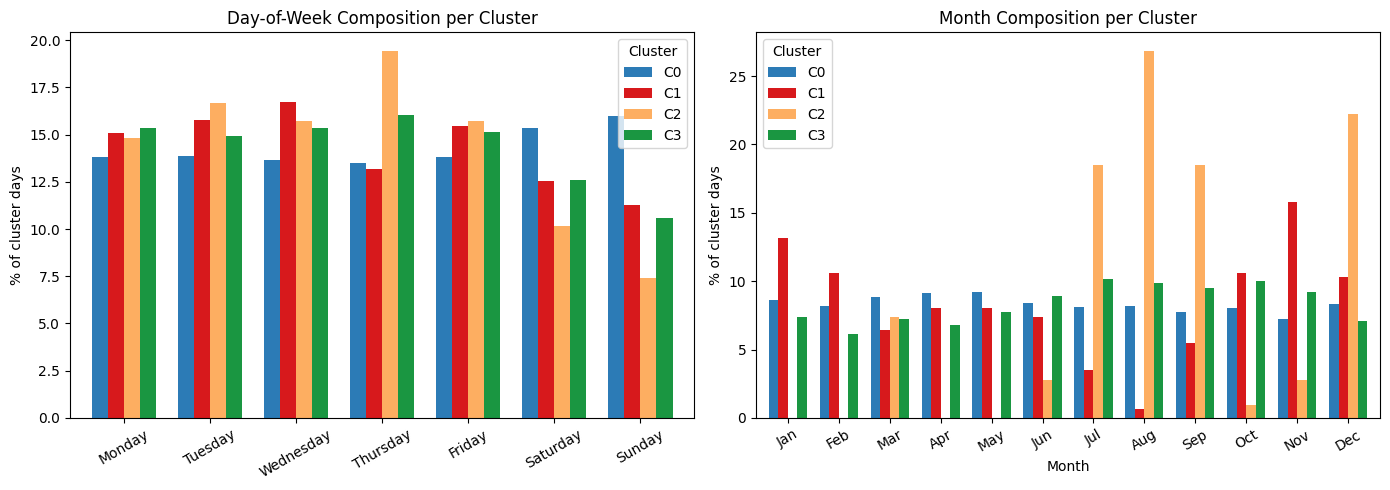

Cluster summary:
         n_days top_month    top_dow
cluster                             
0          2581       May     Sunday
1           311       Nov  Wednesday
2           108       Aug   Thursday
3           991       Jul   Thursday


In [55]:
import datetime

# Attach metadata back to the clustered days
meta = pd.DataFrame({'cluster': pivot_df['cluster']}, index=pivot_df.index)
meta.index = pd.to_datetime(meta.index)
meta['day_of_week'] = meta.index.day_name()
meta['month']       = meta.index.month

DOW_ORDER   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
COLORS      = ['#2c7bb6', '#d7191c', '#fdae61', '#1a9641']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day-of-week distribution per cluster (normalised so each cluster sums to 1)
dow_ct = pd.crosstab(meta['day_of_week'], meta['cluster'], normalize='columns').reindex(DOW_ORDER) * 100
dow_ct.plot(kind='bar', ax=axes[0], color=COLORS, width=0.75)
axes[0].set_title('Day-of-Week Composition per Cluster')
axes[0].set_ylabel('% of cluster days')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend([f'C{c}' for c in range(4)], title='Cluster')

# Month distribution per cluster
month_ct = pd.crosstab(meta['month'], meta['cluster'], normalize='columns') * 100
month_ct.plot(kind='bar', ax=axes[1], color=COLORS, width=0.75)
axes[1].set_title('Month Composition per Cluster')
axes[1].set_ylabel('% of cluster days')
axes[1].set_xlabel('Month')
axes[1].set_xticklabels(MONTH_NAMES, rotation=30)
axes[1].legend([f'C{c}' for c in range(4)], title='Cluster')

plt.tight_layout()
plt.show()

# Summary table
print('Cluster summary:')
summary = meta.groupby('cluster').apply(
    lambda g: pd.Series({
        'n_days': len(g),
        'top_month': MONTH_NAMES[int(g['month'].mode()[0]) - 1],
        'top_dow':   g['day_of_week'].mode()[0],
    })
)
print(summary)

## 7. Interpretation

**What changed from the original approach**  
The first version of this notebook clustered individual hourly observations using features including `price` directly. That caused cluster 3 to be driven by price level rather than time-of-day structure — days with extreme prices (e.g. the 2022 crisis) pulled into their own group regardless of when those prices occurred. Rethinking the approach: instead of clustering hours, we cluster *days* by their 24-hour price profile. Each day becomes a 24-dimensional vector, and standardisation ensures the algorithm focuses on shape (the relative rise and fall across hours) rather than absolute price level.

**What the clusters actually show**  
Cluster 0 is by far the largest (64.7% of days) — it captures the standard price profile, whatever the "normal" day shape looks like across the dataset's 10-year span. Clusters 1 and 2 are very small (7.8% and 2.7%), which suggests they represent genuinely unusual day shapes — candidates include days with negative or near-zero prices driven by renewable oversupply, or days with extreme late-evening spikes. Cluster 3 (24.8%) captures a secondary shape type, likely differing from the baseline in peak hour or intraday spread.

**What the day-of-week and month plots reveal**  
If cluster membership is uniform across days of the week, the shape is not driven by weekend effects. If instead weekends are overrepresented in a cluster, that cluster may capture the low-demand, flat Sunday profile. Similarly, summer months overrepresented in a cluster would point to the solar midday dip that has become more pronounced since 2018.

**What this does not yet answer**  
The clusters here are formed on price shapes, so they are a descriptive summary, not a causal one. A day with a deep midday dip ends up in the same cluster regardless of whether the dip came from solar generation, a public holiday, or a grid export surplus. The `timeofday_clustering_no_pricing.ipynb` notebook takes this further by normalising each day to [0, 1] before clustering, which removes even the relative price level and clusters purely on timing structure.